In [2]:
from google.colab import files
uploaded = files.upload()


Saving diabetic_data.csv to diabetic_data.csv


In [3]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('diabetic_data.csv')
print("Dataset loaded! Shape:", df.shape)
print(df.head())


Dataset loaded! Shape: (101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...     

In [4]:
# Create database in memory
conn = sqlite3.connect('hospital.db')

# Push dataframe into SQL table
df.to_sql('patients', conn, if_exists='replace', index=False)
print("✅ Data loaded into SQL successfully!")


✅ Data loaded into SQL successfully!


In [5]:
query1 = """
SELECT readmitted,
       COUNT(*) as total_count,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM patients), 2) as percentage
FROM patients
GROUP BY readmitted
ORDER BY total_count DESC
"""
result1 = pd.read_sql_query(query1, conn)
print("📊 READMISSION RATES:")
print(result1)


📊 READMISSION RATES:
  readmitted  total_count  percentage
0         NO        54864       53.91
1        >30        35545       34.93
2        <30        11357       11.16


In [6]:
query2 = """
SELECT age,
       COUNT(*) as total_patients,
       SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmitted_30days,
       ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmit_rate_pct
FROM patients
GROUP BY age
ORDER BY age
"""
result2 = pd.read_sql_query(query2, conn)
print("📊 READMISSION BY AGE:")
print(result2)


📊 READMISSION BY AGE:
        age  total_patients  readmitted_30days  readmit_rate_pct
0    [0-10)             161                  3              1.86
1   [10-20)             691                 40              5.79
2   [20-30)            1657                236             14.24
3   [30-40)            3775                424             11.23
4   [40-50)            9685               1027             10.60
5   [50-60)           17256               1668              9.67
6   [60-70)           22483               2502             11.13
7   [70-80)           26068               3069             11.77
8   [80-90)           17197               2078             12.08
9  [90-100)            2793                310             11.10


In [7]:
query3 = """
SELECT time_in_hospital,
       COUNT(*) as total_patients,
       ROUND(AVG(CASE WHEN readmitted='<30' THEN 1 ELSE 0 END)*100, 2) as readmit_rate_pct
FROM patients
GROUP BY time_in_hospital
ORDER BY time_in_hospital
"""
result3 = pd.read_sql_query(query3, conn)
print("📊 HOSPITAL STAY vs READMISSION:")
print(result3)

📊 HOSPITAL STAY vs READMISSION:
    time_in_hospital  total_patients  readmit_rate_pct
0                  1           14208              8.18
1                  2           17224              9.94
2                  3           17756             10.67
3                  4           13924             11.81
4                  5            9966             12.03
5                  6            7539             12.59
6                  7            5859             12.83
7                  8            4391             14.23
8                  9            3002             13.72
9                 10            2342             14.35
10                11            1855             10.51
11                12            1448             13.33
12                13            1210             12.31
13                14            1042             12.96


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries ready!")

✅ Libraries ready!


In [9]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Create target variable — 1 = readmitted within 30 days, 0 = not
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print("✅ Data cleaned!")
print("Shape:", df.shape)
print("Readmission within 30 days:", df['readmit_30'].sum())

✅ Data cleaned!
Shape: (101766, 48)
Readmission within 30 days: 11357


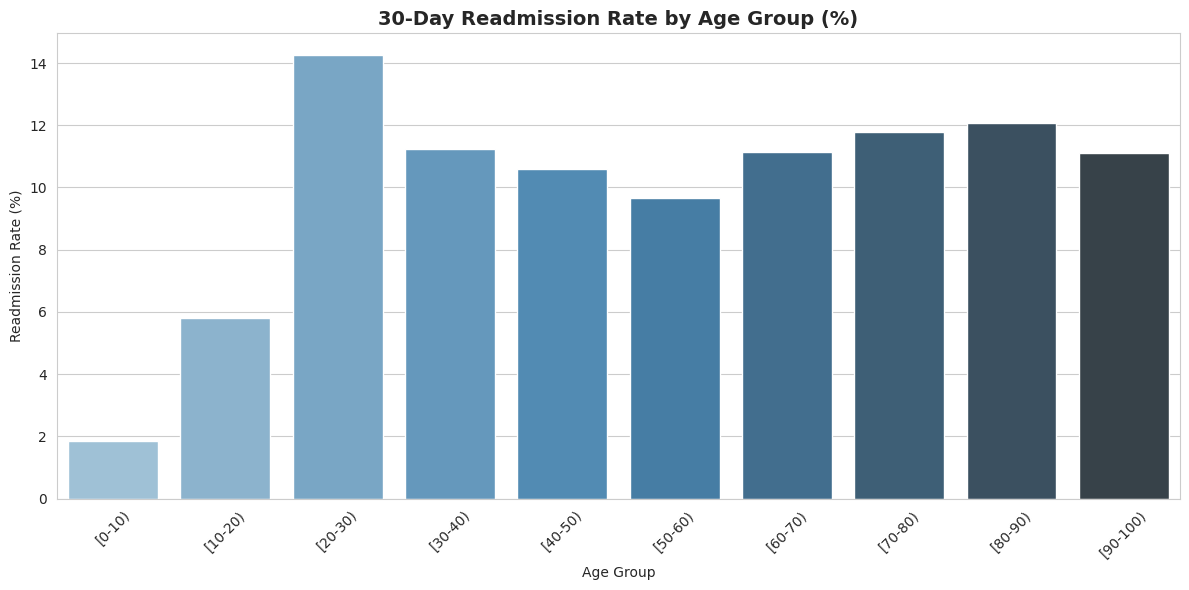

✅ Chart 1 saved!


In [10]:
plt.figure(figsize=(12,6))
age_data = df.groupby('age')['readmit_30'].mean() * 100
sns.barplot(x=age_data.index, y=age_data.values, palette='Blues_d')
plt.title('30-Day Readmission Rate by Age Group (%)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_age_readmission.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

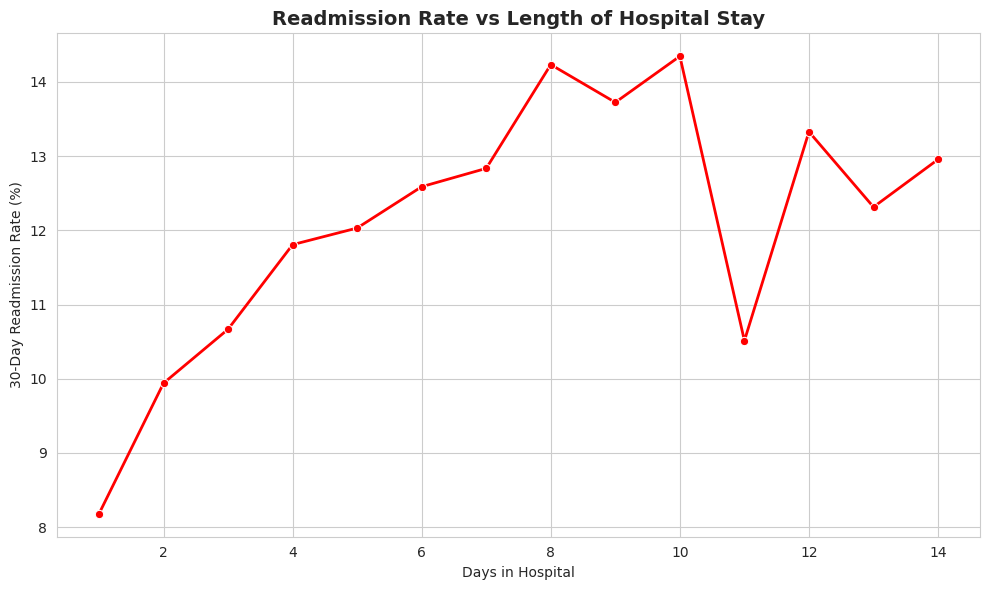

✅ Chart 2 saved!


In [11]:
plt.figure(figsize=(10,6))
stay_data = df.groupby('time_in_hospital')['readmit_30'].mean() * 100
sns.lineplot(x=stay_data.index, y=stay_data.values, marker='o', color='red', linewidth=2)
plt.title('Readmission Rate vs Length of Hospital Stay', fontsize=14, fontweight='bold')
plt.xlabel('Days in Hospital')
plt.ylabel('30-Day Readmission Rate (%)')
plt.tight_layout()
plt.savefig('chart2_stay_readmission.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

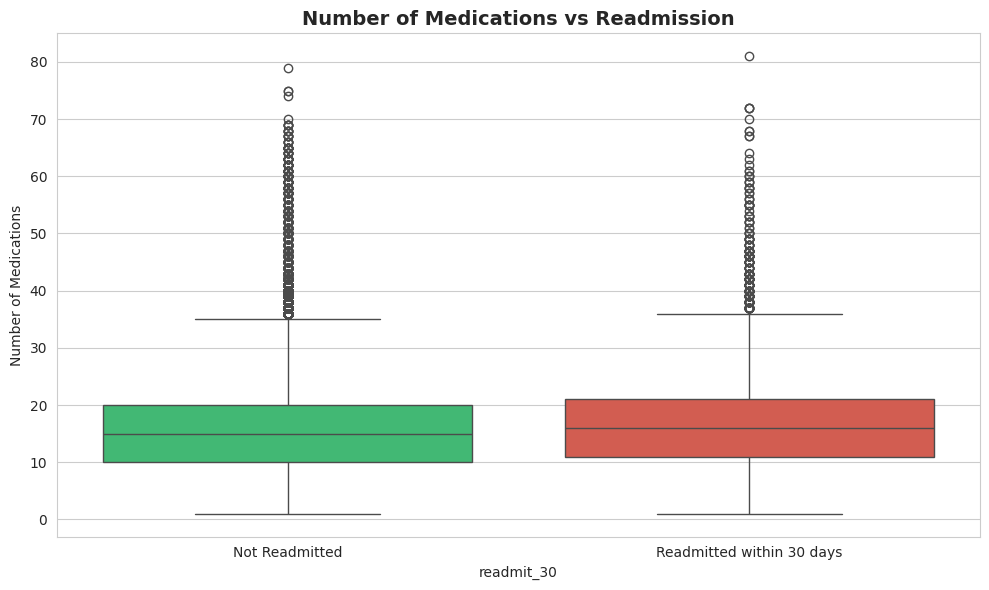

✅ Chart 3 saved!


In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='readmit_30', y='num_medications', palette=['#2ecc71','#e74c3c'])
plt.title('Number of Medications vs Readmission', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Not Readmitted', 'Readmitted within 30 days'])
plt.ylabel('Number of Medications')
plt.tight_layout()
plt.savefig('chart3_medications.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

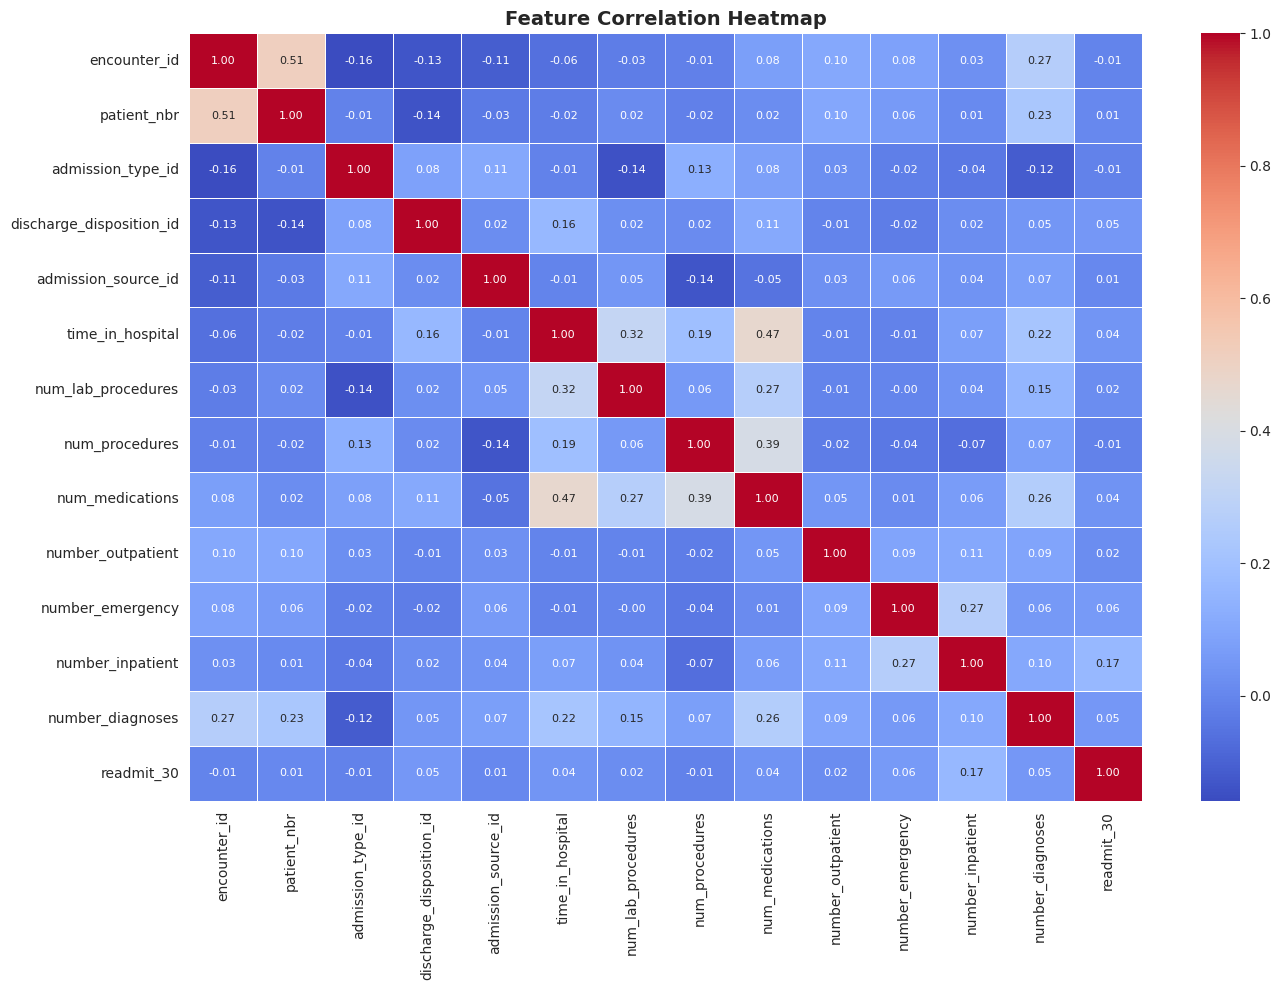

✅ Chart 4 saved!


In [13]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size':8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Encode all text columns to numbers
df_ml = df.copy()
le = LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Features and target
X = df_ml.drop(columns=['readmitted', 'readmit_30'])
y = df_ml['readmit_30']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("✅ Data ready for ML!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

✅ Data ready for ML!
Training samples: 81412
Testing samples: 20354


In [15]:
# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("="*40)
print(f"✅ Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"✅ Random Forest Accuracy:       {rf_acc*100:.2f}%")
print("="*40)
print("\n📊 Detailed Report (Random Forest):")
print(classification_report(y_test, rf.predict(X_test)))

✅ Logistic Regression Accuracy: 88.77%
✅ Random Forest Accuracy:       88.79%

📊 Detailed Report (Random Forest):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.55      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.72      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



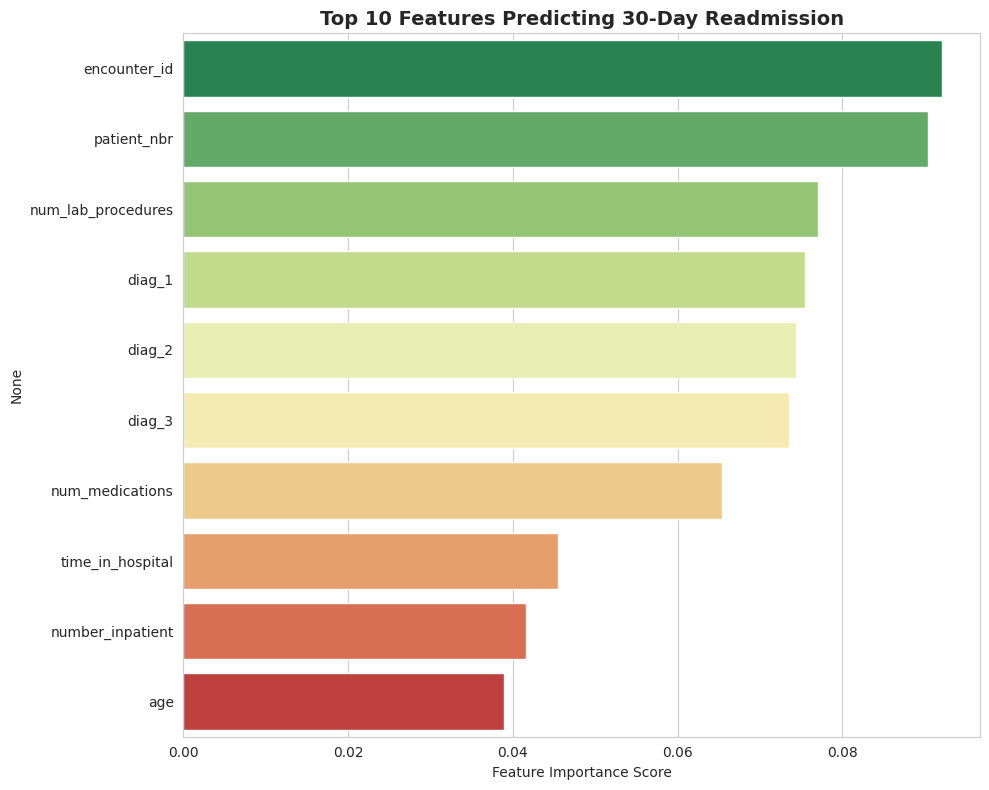

✅ Chart 5 saved!


In [16]:
plt.figure(figsize=(10,8))
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)
sns.barplot(x=top10.values, y=top10.index, palette='RdYlGn_r')
plt.title('Top 10 Features Predicting 30-Day Readmission', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('chart5_feature_importance.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

In [17]:
# Save cleaned file to use in Power BI
df_clean = df.copy()
df_clean.to_csv('cleaned_patients.csv', index=False)

# Download it to your computer
from google.colab import files
files.download('cleaned_patients.csv')
files.download('chart1_age_readmission.png')
files.download('chart2_stay_readmission.png')
files.download('chart3_medications.png')
files.download('chart4_heatmap.png')
files.download('chart5_feature_importance.png')

print("✅ All files downloaded! Check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded! Check your Downloads folder.
